In [33]:
import sys
import os

# Add the parent directory to the Python path
sys.path.append(os.path.abspath('..'))

In [34]:
from get_llm import get_model

In [35]:
from langgraph.graph import MessagesState
from langchain_core.messages import SystemMessage

# Graph State
class Messages(MessagesState):
    summary: str = ""


def converstation_node(state: Messages) -> Messages:
    messages = state.get("messages")
    
    system_message = "You are a helpful assistent, help the user with its query"
    
    summary = state.get("summary")
    
    if summary != "":
        system_message += (
            f"\n\nThis is the current summary of the conversation till now: {summary}"
        )
    
    model = get_model()
    response = model.invoke([SystemMessage(content=system_message)] + messages)

    return {"messages": [response.content]}
    # return Messages(messages=response.content)

In [36]:
from langchain_core.messages import RemoveMessage


def summarize_conversation(state: Messages) -> Messages:

    system_message = (
        "You are a expert summarizer, your task is to summarize this conversation"
    )

    summary = state.get("summary")

    if summary != "":
        system_message += f"\n\nThis is the current summary of the conversation till now: {summary}\n\n Create the summary by taking into account the current summary"

    model = get_model()

    response = model.invoke(
        [SystemMessage(content=system_message)] + state.get("messages")
    )

    remaining_messages = [RemoveMessage(id=m.id) for m in state.get("messages")[:-2]]

    return Messages(summary=response.content, messages=remaining_messages)

In [37]:
from langgraph.graph import END
from typing import Literal

def should_continue(state: Messages) -> Literal["summarize_conversation", "__end__"]:
    
    # if messages > 6 summarize it
    
    messages = state.get("messages")
    
    if len(messages) > 6:
        return "summarize_conversation"
    
    return END

In [38]:
from langgraph.graph import StateGraph, END, START

builder = StateGraph(state_schema=Messages)

builder.add_node("converstation_node", converstation_node)
builder.add_node("summarize_conversation", summarize_conversation)

builder.add_edge(START, "converstation_node")
builder.add_conditional_edges("converstation_node", should_continue)
builder.add_edge("summarize_conversation", END)


In [39]:
# adding memory
from langgraph.checkpoint.memory import InMemorySaver

memory = InMemorySaver()

graph = builder.compile(checkpointer=memory)

## Visulization

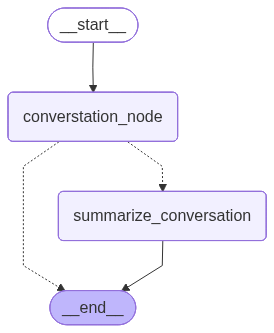

In [40]:
from IPython.display import Image
display(Image(graph.get_graph().draw_mermaid_png()))

### Adding checkpointer

In [41]:
from langchain_core.runnables.config import RunnableConfig
config = RunnableConfig(configurable={"thread_id" : 1})

### Stages of streaming

1. Values -> Stream the full state of graph after each node is called
2. updates -> Update of each state is streamed

In [42]:
# Update

from langchain_core.messages import HumanMessage

for chunk in graph.stream({'messages' : [HumanMessage(content="Hey I am Rohit")]}, config=config, stream_mode="updates"):
    print(chunk)

{'converstation_node': {'messages': ["Hi Rohit, it's nice to meet you! How can I help you today?"]}}


In [44]:
from langchain_core.runnables.config import RunnableConfig
config = RunnableConfig(configurable={"thread_id" : 2})

In [45]:
# values

from langchain_core.messages import HumanMessage

for chunk in graph.stream({'messages' : [HumanMessage(content="Hey I am Rohit")]}, config=config, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hey I am Rohit', additional_kwargs={}, response_metadata={}, id='62b2488e-8090-4b32-9a7c-3e5c9c624f02')]}
{'messages': [HumanMessage(content='Hey I am Rohit', additional_kwargs={}, response_metadata={}, id='62b2488e-8090-4b32-9a7c-3e5c9c624f02'), HumanMessage(content="Hi Rohit, it's nice to meet you! How can I help you today?", additional_kwargs={}, response_metadata={}, id='7f54c122-0be2-486a-bc5f-d9fbcd029cde')]}


### Token Level Streaming

Here the event dict have a few keys

1. data -> data wrt event
2. metadata -> metadata of the event, also contain the node which is emmiting the event
3. event -> Type of event
4. name -> Name of event


In [46]:
from langchain_core.runnables.config import RunnableConfig
config = RunnableConfig(configurable={"thread_id" : 3})

In [47]:
from langchain_core.messages import HumanMessage

async for event in graph.astream_events({'messages' : [HumanMessage(content="Hey I am Rohit")]}, config=config, stream_mode="values"):
    print(f"event_name: {event['name']} | node_name: {event['metadata'].get('langgraph_node', '')} | Type: {event['event']}")

event_name: LangGraph | node_name:  | Type: on_chain_start
event_name: LangGraph | node_name:  | Type: on_chain_stream
event_name: converstation_node | node_name: converstation_node | Type: on_chain_start
event_name: ChatGoogleGenerativeAI | node_name: converstation_node | Type: on_chat_model_start
event_name: ChatGoogleGenerativeAI | node_name: converstation_node | Type: on_chat_model_stream
event_name: ChatGoogleGenerativeAI | node_name: converstation_node | Type: on_chat_model_stream
event_name: ChatGoogleGenerativeAI | node_name: converstation_node | Type: on_chat_model_stream
event_name: ChatGoogleGenerativeAI | node_name: converstation_node | Type: on_chat_model_end
event_name: should_continue | node_name: converstation_node | Type: on_chain_start
event_name: should_continue | node_name: converstation_node | Type: on_chain_end
event_name: converstation_node | node_name: converstation_node | Type: on_chain_stream
event_name: converstation_node | node_name: converstation_node | Typ

### Lets just get the ai message

In [53]:
from langchain_core.runnables.config import RunnableConfig
config_4 = RunnableConfig(configurable={"thread_id" : "55"})

In [54]:
from langchain_core.messages import HumanMessage

async for event in graph.astream_events({'messages' : [HumanMessage(content="Explain me prime numbers in 2 sentences")]}, config=config_4):
    if event["name"] == "ChatGoogleGenerativeAI":
        print(event["data"])

{'input': {'messages': [[SystemMessage(content='You are a helpful assistent, help the user with its query\n\nThis is the current summary of the conversation till now: None', additional_kwargs={}, response_metadata={}), HumanMessage(content='Explain me prime numbers in 2 sentences', additional_kwargs={}, response_metadata={}, id='ba9c54df-98cc-481d-a904-8a2556f248dc')]]}}
{'chunk': AIMessageChunk(content='Prime', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d49f5-fa51-7213-a62e-cfdec244b6db', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' numbers are whole numbers greater than 1 that have only two divisors: 1', additional_kwargs={}, response_metadata={'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019d49f5-fa51-7213-a62e-cfdec244b6db', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[])}
{'chunk': AIMessageChunk(content=' and themselves. For ex